In [1]:
!pip install datasets transformers matplotlib seaborn -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [2]:
# %%
# Cài đặt thư viện
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer
import torch
from torch.utils.data import DataLoader

# Tải GLUE MNLI
raw_datasets = load_dataset("nyu-mll/glue", "mnli")

print("--- KÍCH THƯỚC TOÀN BỘ DATASET GỐC ---")
print(f"Tập Huấn luyện (Train):          {raw_datasets['train'].num_rows:,} mẫu")
print(f"Tập Kiểm định trùng miền (Val Matched):    {raw_datasets['validation_matched'].num_rows:,} mẫu")
print(f"Tập Kiểm định lệch miền (Val Mismatched): {raw_datasets['validation_mismatched'].num_rows:,} mẫu")

d:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 67870437-5278-4d02-b1c5-269dc38b9edf)')' thrown while requesting HEAD https://huggingface.co/datasets/nyu-mll/glue/resolve/main/README.md
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 1b24bf36-747b-49a1-bde1-79b3a98a907e)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/datasets/nyu-mll/glue/bcdcba79d07bc864c1c254ccfcedcce55bcc9a8c/README.md
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetE

--- KÍCH THƯỚC TOÀN BỘ DATASET GỐC ---
Tập Huấn luyện (Train):          392,702 mẫu
Tập Kiểm định trùng miền (Val Matched):    9,815 mẫu
Tập Kiểm định lệch miền (Val Mismatched): 9,832 mẫu


Chuyển toàn bộ dữ liệu dạng Arrow của Hugging Face sang Pandas DataFrame

In [3]:
# %%
# Chuyển đổi dữ liệu sang Pandas DataFrame
print("Đang cấu trúc lại dữ liệu sang dạng bảng...")
train_df = raw_datasets["train"].to_pandas()
val_matched_df = raw_datasets["validation_matched"].to_pandas()
val_mismatched_df = raw_datasets["validation_mismatched"].to_pandas()

# Ánh xạ nhãn số sang định dạng ngữ nghĩa
label_mapping = {0: "Entailment (Hệ quả)", 1: "Neutral (Trung hòa)", 2: "Contradiction (Mâu thuẫn)"}

print("\n--- CẤU TRÚC ĐỊNG DẠNG CỦA MỘT DÒNG DỮ LIỆU ---")
print(train_df.info())

print("\n--- QUAN SÁT NGẪU NHIÊN 3 CẶP CÂU TRONG TẬP TRAIN ---")
for i in range(3):
    idx = np.random.randint(0, len(train_df))
    print(f"\nMẫu thứ {idx}:")
    print(f"  - Premise (Tiền đề): {train_df['premise'].iloc[idx]}")
    print(f"  - Hypothesis (Giả thuyết): {train_df['hypothesis'].iloc[idx]}")
    print(f"  - Nhãn: {train_df['label'].iloc[idx]} -> {label_mapping[train_df['label'].iloc[idx]]}")

Đang cấu trúc lại dữ liệu sang dạng bảng...

--- CẤU TRÚC ĐỊNG DẠNG CỦA MỘT DÒNG DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 392702 entries, 0 to 392701
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   premise     392702 non-null  str  
 1   hypothesis  392702 non-null  str  
 2   label       392702 non-null  int64
 3   idx         392702 non-null  int32
dtypes: int32(1), int64(1), str(2)
memory usage: 74.2 MB
None

--- QUAN SÁT NGẪU NHIÊN 3 CẶP CÂU TRONG TẬP TRAIN ---

Mẫu thứ 45594:
  - Premise (Tiền đề): The creation of the H-2A program was controversial, given the history of prior temporary agricultural programs such as the Bracero program.
  - Hypothesis (Giả thuyết): The creation of the H-2A program we met with criticism.
  - Nhãn: 1 -> Neutral (Trung hòa)

Mẫu thứ 234017:
  - Premise (Tiền đề): While this guidance focuses only on the reliability of data in terms of accuracy and completeness, other data qu

EDA - Kiểm tra sự cân bằng phân phối nhãn (Class Distribution)

C:\Users\Tun tun\AppData\Local\Temp\ipykernel_18176\2674449867.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_mapping[i] for i in range(3)])


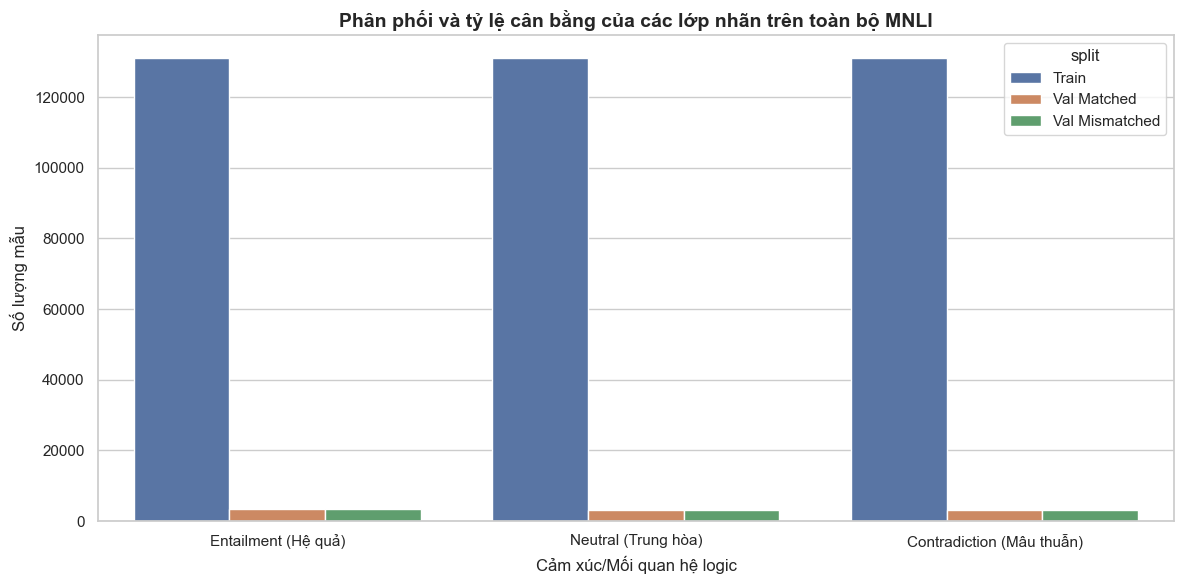

--- TỶ LỆ PHẦN TRĂM CHI TIẾT CÁC LỚP TRÊN TẬP TRAIN (%) ---
label
0    33.332909
1    33.333164
2    33.333928
Name: proportion, dtype: float64


In [4]:
# %%
# Gộp các tập lại để vẽ biểu đồ so sánh phân phối nhãn
train_df['split'] = 'Train'
val_matched_df['split'] = 'Val Matched'
val_mismatched_df['split'] = 'Val Mismatched'
df_combined = pd.concat([train_df[['label', 'split']], val_matched_df[['label', 'split']], val_mismatched_df[['label', 'split']]])

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ cột tỷ lệ phần trăm
ax = sns.countplot(data=df_combined, x='label', hue='split', palette='deep')
plt.title('Phân phối và tỷ lệ cân bằng của các lớp nhãn trên toàn bộ MNLI', fontsize=14, fontweight='bold')
plt.xlabel('Cảm xúc/Mối quan hệ logic', fontsize=12)
plt.ylabel('Số lượng mẫu', fontsize=12)
ax.set_xticklabels([label_mapping[i] for i in range(3)])

plt.tight_layout()
plt.show()

# Hiển thị bảng số liệu phần trăm chi tiết để copy vào báo cáo
print("--- TỶ LỆ PHẦN TRĂM CHI TIẾT CÁC LỚP TRÊN TẬP TRAIN (%) ---")
print(train_df['label'].value_counts(normalize=True).sort_index() * 100)

EDA - Thống kê độ dài từ vựng sâu để chọn tham số mạng

Đang tính toán độ dài văn bản thô...


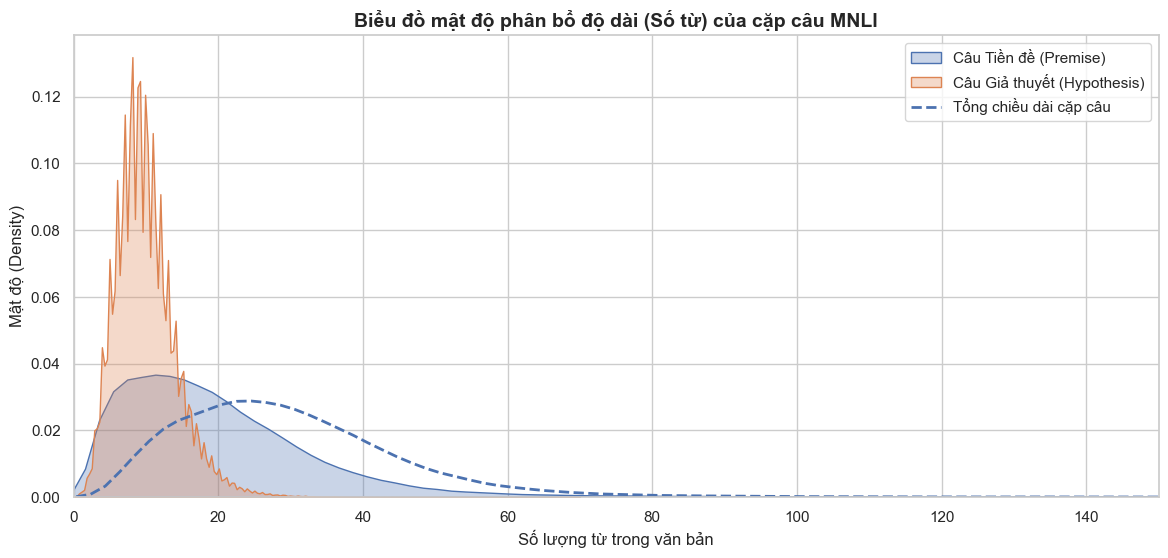

--- THỐNG KÊ PHÂN VỊ ĐỘ DÀI TỔNG CỦA CẶP CÂU ---
Mức Trung vị (50% số câu có độ dài dưới):  27 từ
Mốc 90% số câu trong hệ thống có độ dài dưới: 49 từ
Mốc 95% số câu trong hệ thống có độ dài dưới: 57 từ
Mốc 99% số câu trong hệ thống có độ dài dưới: 81 từ


In [5]:
# %%
# Tính số lượng từ bằng cách chia khoảng trắng trên toàn bộ dữ liệu lớn
print("Đang tính toán độ dài văn bản thô...")
train_df['premise_len'] = train_df['premise'].apply(lambda x: len(str(x).split()))
train_df['hypothesis_len'] = train_df['hypothesis'].apply(lambda x: len(str(x).split()))
train_df['total_len'] = train_df['premise_len'] + train_df['hypothesis_len']

# Vẽ biểu đồ mật độ phân bổ độ dài chuỗi
plt.figure(figsize=(14, 6))
sns.kdeplot(data=train_df['premise_len'], label='Câu Tiền đề (Premise)', fill=True, alpha=0.3)
sns.kdeplot(data=train_df['hypothesis_len'], label='Câu Giả thuyết (Hypothesis)', fill=True, alpha=0.3)
sns.kdeplot(data=train_df['total_len'], label='Tổng chiều dài cặp câu', fill=False, linestyle="--", linewidth=2)

plt.title('Biểu đồ mật độ phân bổ độ dài (Số từ) của cặp câu MNLI', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng từ trong văn bản')
plt.ylabel('Mật độ (Density)')
plt.xlim(0, 150) # Giới hạn trục X để nhìn rõ vùng tập trung dữ liệu
plt.legend()
plt.show()

# Tính toán các chỉ số phân vị cốt lõi
print("--- THỐNG KÊ PHÂN VỊ ĐỘ DÀI TỔNG CỦA CẶP CÂU ---")
percentiles = train_df['total_len'].quantile([0.5, 0.75, 0.90, 0.95, 0.99])
print(f"Mức Trung vị (50% số câu có độ dài dưới):  {percentiles[0.5]:.0f} từ")
print(f"Mốc 90% số câu trong hệ thống có độ dài dưới: {percentiles[0.9]:.0f} từ")
print(f"Mốc 95% số câu trong hệ thống có độ dài dưới: {percentiles[0.95]:.0f} từ")
print(f"Mốc 99% số câu trong hệ thống có độ dài dưới: {percentiles[0.99]:.0f} từ")

Preprocessing

In [ ]:
# %%
# 1. Khởi tạo bộ Tokenizer tương ứng với mô hình Transformer (đang để tạm là BERT-uncased)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 2. Xây dựng hàm mã hóa cặp câu đồng thời
def tokenize_pair_dataset(examples):
    return tokenizer(
        examples["premise"],        # Câu A
        examples["hypothesis"],     # Câu B
        padding="max_length",       # Đệm thêm [PAD] nếu chuỗi ngắn hơn max_length
        truncation=True,             # Cắt bỏ đuôi nếu chuỗi vượt quá max_length
        max_length=128               # Con số tối ưu chứng minh từ kết quả EDA ở Cell 4
    )

print("Bắt đầu quy trình mã hóa Tokenization...")
# Áp dụng song song hóa bằng batched=True để tăng tốc độ xử lý tối đa
tokenized_datasets = raw_datasets.map(tokenize_pair_dataset, batched=True)

# 3. Loại bỏ hoàn toàn các cột chữ thô cấu trúc cũ để giải phóng bộ nhớ RAM
columns_to_drop = ["premise", "hypothesis", "idx"]
tokenized_datasets = tokenized_datasets.remove_columns(columns_to_drop)

# Đổi tên cột 'label' thành 'labels' để đồng bộ với thư viện PyTorch
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# 4. Ép định dạng cấu trúc toàn bộ dữ liệu sang PyTorch Tensors
tokenized_datasets.set_format("torch")

print("\nMã hóa thành công!")
print("Cấu trúc các tập dữ liệu số thu được:")
print(tokenized_datasets)

# 5. Tạo các DataLoader hoàn chỉnh phục vụ trực tiếp cho việc huấn luyện sau này
BATCH_SIZE = 32
train_dataloader = DataLoader(tokenized_datasets["train"], shuffle=True, batch_size=BATCH_SIZE)
val_matched_dataloader = DataLoader(tokenized_datasets["validation_matched"], batch_size=BATCH_SIZE)
val_mismatched_dataloader = DataLoader(tokenized_datasets["validation_mismatched"], batch_size=BATCH_SIZE)

# --- TRÍCH XUẤT KIỂM TRA THỬ BATCH ĐẦU TIÊN ---
sample_batch = next(iter(train_dataloader))
print("\n--- KIỂM TRA ĐẦU RA HOÀN CHỈNH CỦA MỘT BATCH NẠP VÀO TRANSFORMER ---")
print(f"Keys: {list(sample_batch.keys())}")
print(f"Shape của Input IDs matrix (X):      {sample_batch['input_ids'].shape} -> [Batch_size, Seq_len]")
print(f"Shape của Attention Mask matrix:     {sample_batch['attention_mask'].shape}")
if 'token_type_ids' in sample_batch:
    print(f"Shape của Token Type IDs (Segment):  {sample_batch['token_type_ids'].shape} -> (Đánh dấu phân tách câu A/B)")
print(f"Shape của Labels vector (Y):         {sample_batch['labels'].shape} -> (Nhãn đích gồm 3 lớp: 0, 1, 2)")

'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 2fecd05a-04cd-499a-9b6b-4910c85e82e7)')' thrown while requesting HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: c4430175-dc5f-4db8-8f2b-a36d4a243fb9)')' thrown while requesting HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 2s [Retry 2/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 1f91f296-8583-4d34-a144-77a0b5ed9102)')' thrown while requesting HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json
Retry

Bắt đầu quy trình mã hóa Tokenization...


Map: 100%|██████████| 9847/9847 [00:00<00:00, 12778.31 examples/s]



Mã hóa thành công!
Cấu trúc các tập dữ liệu số thu được:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 392702
    })
    validation_matched: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9815
    })
    validation_mismatched: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9832
    })
    test_matched: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9796
    })
    test_mismatched: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9847
    })
})

--- KIỂM TRA ĐẦU RA HOÀN CHỈNH CỦA MỘT BATCH NẠP VÀO TRANSFORMER ---
Shape của Input IDs matrix (X):   torch.Size([32, 128]) -> [Batch_size, Seq_len]
Shape của Attention Mask matrix:  torch.Size([32, 128])
Shape của Token Type

## Xây 2 mô hình cho MNLI (Transformer gốc vs Transformer + SwiGLU MLP)

In [9]:
# %%
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

def masked_mean_pooling(x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """
    x: (batch, seq_len, hidden)
    attention_mask: (batch, seq_len) with 1 for real tokens, 0 for PAD
    """
    mask = attention_mask.unsqueeze(-1).to(dtype=x.dtype)  # (batch, seq_len, 1)
    x = x * mask
    denom = mask.sum(dim=1).clamp(min=1.0)
    return x.sum(dim=1) / denom

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1), :]

class OriginalTransformerMNLI(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_classes: int = 3,
        d_model: int = 256,
        nhead: int = 8,
        num_layers: int = 3,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
        max_len: int = 512,
        type_vocab_size: int = 2,
    ):
        super().__init__()
        self.word_embedding = nn.Embedding(vocab_size, d_model)
        self.type_embedding = nn.Embedding(type_vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        token_type_ids: torch.Tensor | None = None,
    ) -> torch.Tensor:
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)

        x = self.word_embedding(input_ids) + self.type_embedding(token_type_ids)
        x = self.pos_encoder(x)

        key_padding_mask = attention_mask == 0  # True = PAD
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)

        pooled = masked_mean_pooling(x, attention_mask)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

class SwiGLU(nn.Module):
    def __init__(self, in_features: int, hidden_features: int):
        super().__init__()
        self.w1 = nn.Linear(in_features, hidden_features)
        self.w2 = nn.Linear(in_features, hidden_features)
        self.w3 = nn.Linear(hidden_features, in_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        swish_out = F.silu(self.w1(x))
        return self.w3(swish_out * self.w2(x))

class SwiGLUTransformerEncoderLayer(nn.Module):
    def __init__(self, d_model: int, nhead: int, dim_feedforward: int = 1024, dropout: float = 0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.mlp = SwiGLU(in_features=d_model, hidden_features=dim_feedforward)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        src: torch.Tensor,
        src_key_padding_mask: torch.Tensor | None = None,
        is_causal: bool = False,
    ) -> torch.Tensor:
        attn_out, _ = self.self_attn(
            src, src, src,
            key_padding_mask=src_key_padding_mask,
            need_weights=False,
            is_causal=is_causal,
        )
        src = self.norm1(src + self.dropout(attn_out))
        mlp_out = self.mlp(src)
        src = self.norm2(src + self.dropout(mlp_out))
        return src

class SwiGLUTransformerMNLI(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_classes: int = 3,
        d_model: int = 256,
        nhead: int = 8,
        num_layers: int = 3,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
        max_len: int = 512,
        type_vocab_size: int = 2,
    ):
        super().__init__()
        self.word_embedding = nn.Embedding(vocab_size, d_model)
        self.type_embedding = nn.Embedding(type_vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)
        self.layers = nn.ModuleList([
            SwiGLUTransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        token_type_ids: torch.Tensor | None = None,
    ) -> torch.Tensor:
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)

        x = self.word_embedding(input_ids) + self.type_embedding(token_type_ids)
        x = self.pos_encoder(x)

        key_padding_mask = attention_mask == 0  # True = PAD
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=key_padding_mask)

        pooled = masked_mean_pooling(x, attention_mask)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

In [10]:
# %%
# Hyperparameters gợi ý (có thể tinh chỉnh sau)
NUM_CLASSES = 3
VOCAB_SIZE = tokenizer.vocab_size  # phù hợp BERT tokenizer
D_MODEL = 256
N_HEAD = 8
NUM_LAYERS = 3
DIM_FEEDFORWARD = 1024
DROPOUT = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model_original = OriginalTransformerMNLI(
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_len=128,
).to(device)

model_swiglu = SwiGLUTransformerMNLI(
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_len=128,
).to(device)

print(f"#Params Original: {sum(p.numel() for p in model_original.parameters() if p.requires_grad):,}")
print(f"#Params SwiGLU  : {sum(p.numel() for p in model_swiglu.parameters() if p.requires_grad):,}")

# Quick sanity check: forward pass 1 batch
batch = next(iter(train_dataloader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
token_type_ids = batch.get("token_type_ids")
if token_type_ids is not None:
    token_type_ids = token_type_ids.to(device)

with torch.no_grad():
    logits_o = model_original(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
    logits_s = model_swiglu(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)

print("Logits shape (Original):", logits_o.shape)  # (batch, 3)
print("Logits shape (SwiGLU)  :", logits_s.shape)  # (batch, 3)

Device: cuda
#Params Original: 10,184,195
#Params SwiGLU  : 10,973,699
Logits shape (Original): torch.Size([32, 3])
Logits shape (SwiGLU)  : torch.Size([32, 3])
